In [9]:
df_raw = pd.read_csv("Creditcard_data.csv")
df = df_raw.copy()



In [10]:
import pandas as pd
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN
from imblearn.combine import SMOTETomek


In [11]:
pip install pandas

In [12]:
from imblearn.under_sampling import RandomUnderSampler

X = df.drop("Class", axis=1)
y = df["Class"]

rus = RandomUnderSampler(random_state=42)
X_bal, y_bal = rus.fit_resample(X, y)


In [13]:
samples = []
seeds = [11, 22, 33, 44, 55]

for s in seeds:
    sample = X_bal.sample(frac=0.8, random_state=s)
    samples.append(sample)


In [14]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks

sampling_methods = {
    "S1_RUS": RandomUnderSampler(),
    "S2_ROS": RandomOverSampler(),
    "S3_SMOTE": SMOTE(),
    "S4_SMOTEENN": SMOTEENN(),
    "S5_Tomek": TomekLinks()
}

In [15]:
results.loc[model_name, sampling_name] = round(acc * 100, 2)


AttributeError: 'list' object has no attribute 'loc'

In [20]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from imblearn.over_sampling import SMOTE
from sklearn.cluster import KMeans


# read the dataset
df_data = pd.read_csv("Creditcard_data.csv")

x_data = df_data.drop("Class", axis=1)
y_data = df_data["Class"]


# balance the dataset using smote
smote_obj = SMOTE(random_state=5)
x_bal, y_bal = smote_obj.fit_resample(x_data, y_data)

df_balanced = pd.DataFrame(x_bal, columns=x_data.columns)
df_balanced["Class"] = y_bal


# sample size using cochran formula
z_val = 1.96
prob = 0.5
err = 0.05

req_n = int(np.ceil((z_val ** 2 * prob * (1 - prob)) / (err ** 2)))


# function to create samples
def create_samples(input_df, size):

    output_samples = {}

    # simple random sampling
    output_samples["Random"] = input_df.sample(
        n=size, random_state=10
    )

    # systematic sampling
    step_size = max(len(input_df) // size, 1)
    output_samples["Systematic"] = input_df.iloc[::step_size].head(size)

    # stratified sampling
    strat_df = input_df.groupby("Class", group_keys=False).apply(
        lambda d: d.sample(size // 2, random_state=12)
    )
    output_samples["Stratified"] = strat_df

    # cluster sampling
    temp_df = input_df.copy()
    k_model = KMeans(n_clusters=7, random_state=15)
    temp_df["cluster_no"] = k_model.fit_predict(
        temp_df.drop("Class", axis=1)
    )

    selected = temp_df["cluster_no"].unique()[:3]
    clust_df = temp_df[temp_df["cluster_no"].isin(selected)].sample(
        n=size, replace=True, random_state=18
    )

    output_samples["Cluster"] = clust_df.drop("cluster_no", axis=1)

    # bootstrap sampling
    output_samples["Bootstrap"] = input_df.sample(
        n=size, replace=True, random_state=20
    )

    return output_samples


sample_sets = create_samples(df_balanced, req_n)


# models used
model_list = {
    "M1_LogReg": LogisticRegression(max_iter=1000),
    "M2_RandomForest": RandomForestClassifier(random_state=25),
    "M3_SVM": SVC(),
    "M4_DecisionTree": DecisionTreeClassifier(),
    "M5_GradientBoost": GradientBoostingClassifier()
}


# training and testing
final_rows = []

for samp_key, samp_df in sample_sets.items():

    x_samp = samp_df.drop("Class", axis=1)
    y_samp = samp_df["Class"]

    x_tr, x_te, y_tr, y_te = train_test_split(
        x_samp, y_samp, test_size=0.25, random_state=30
    )

    row_data = {"Sampling": samp_key}

    for mdl_name, mdl in model_list.items():
        mdl.fit(x_tr, y_tr)
        y_pred = mdl.predict(x_te)
        acc_val = accuracy_score(y_te, y_pred)

        row_data[mdl_name] = round(acc_val*100  , 2)

    final_rows.append(row_data)


# save results
result_df = pd.DataFrame(final_rows)
result_df.to_csv("Sampling_Results.csv", index=False)

print(result_df)


/tmp/ipython-input-1948670484.py:54: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  strat_df = input_df.groupby("Class", group_keys=False).apply(


     Sampling  M1_LogReg  M2_RandomForest  M3_SVM  M4_DecisionTree  \
0      Random      93.81           100.00   78.35            94.85   
1  Systematic      92.78            98.97   78.35            97.94   
2  Stratified      90.62           100.00   63.54            97.92   
3     Cluster      95.88            98.97   68.04            98.97   
4   Bootstrap      91.75           100.00   71.13            98.97   

   M5_GradientBoost  
0             96.91  
1            100.00  
2            100.00  
3            100.00  
4             98.97  


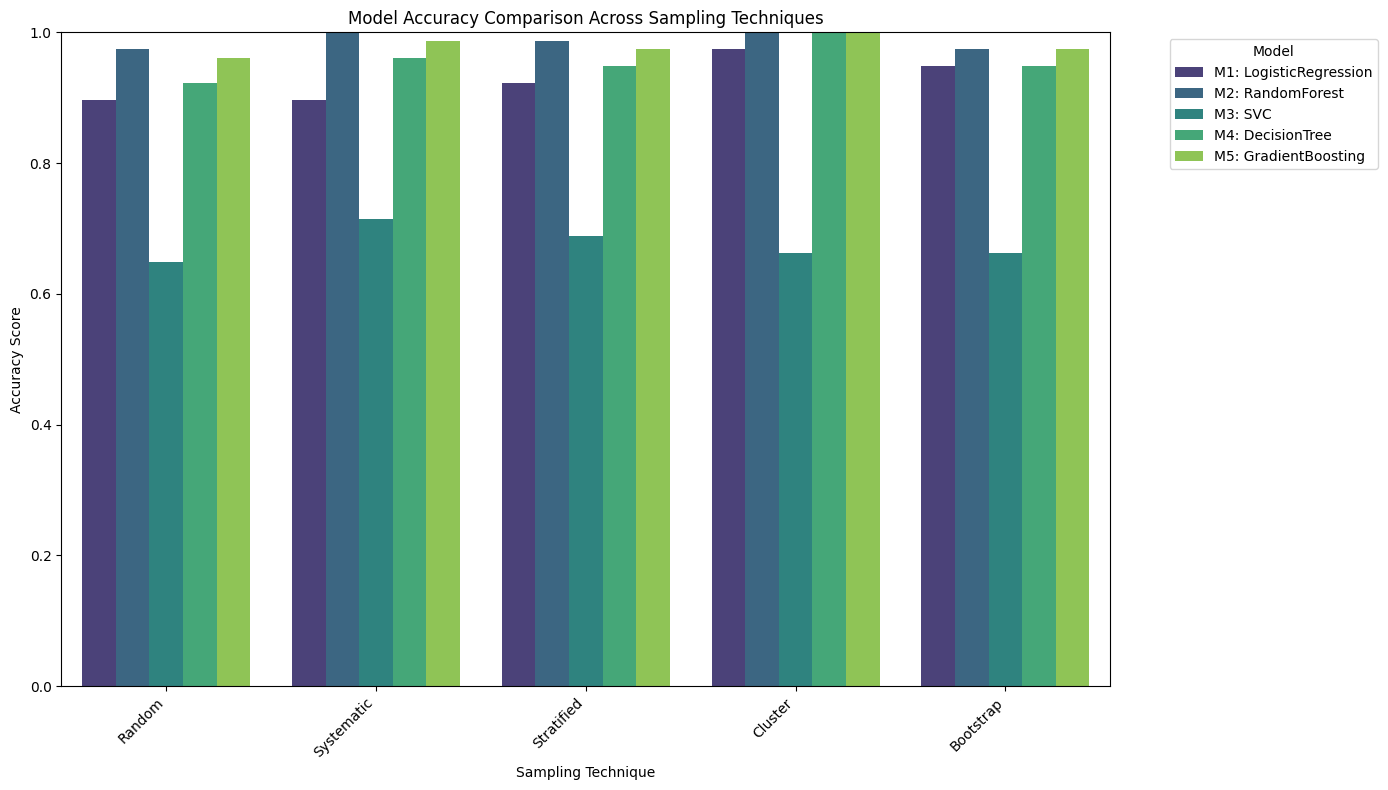

Plot saved to model_accuracy_comparison.png


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure results_df is available. Assuming it's generated from cell ptVsxGnADrYW
# If you run this cell independently, ensure results_df is loaded or generated first.

# Prepare data for plotting
plot_df = results_df.set_index('Sampling Technique').stack().reset_index()
plot_df.columns = ['Sampling Technique', 'Model', 'Accuracy']

plt.figure(figsize=(14, 8))
sns.barplot(data=plot_df, x='Sampling Technique', y='Accuracy', hue='Model', palette='viridis')
plt.title('Model Accuracy Comparison Across Sampling Techniques')
plt.ylabel('Accuracy Score')
plt.xlabel('Sampling Technique')
plt.ylim(0, 1) # Accuracy scores are between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save the plot
image_path = 'model_accuracy_comparison.png'
plt.savefig(image_path)
plt.show()

print(f"Plot saved to {image_path}")

/tmp/ipython-input-3109173022.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=data, palette='coolwarm')
/tmp/ipython-input-3109173022.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=balanced_df, palette='coolwarm')


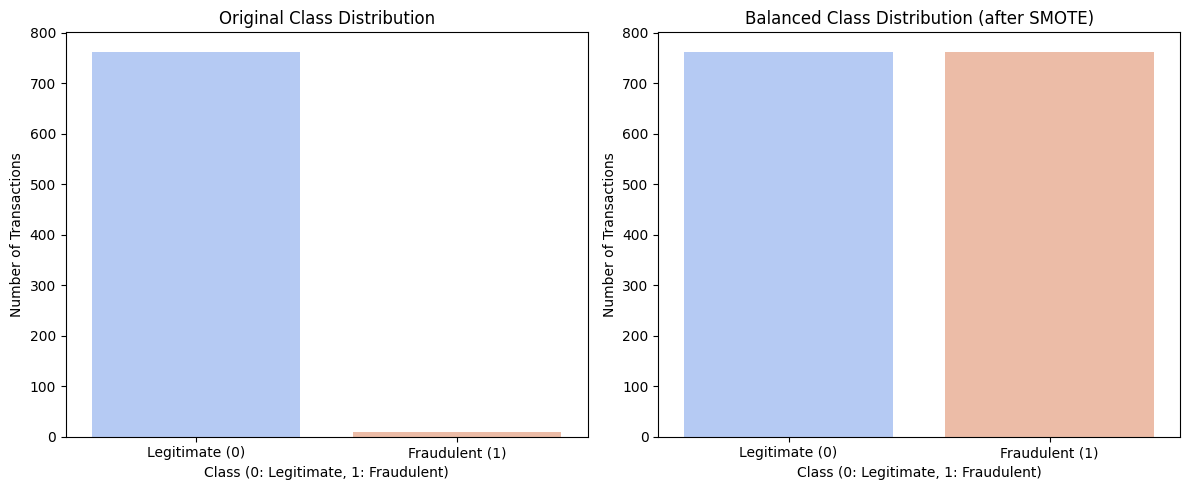

Class distribution plot saved to class_distribution.png


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'data' and 'balanced_df' are available. These are typically created early in the notebook.
# If running this cell independently, ensure the data loading and SMOTE steps are executed first.

plt.figure(figsize=(12, 5))

# Subplot 1: Original Class Distribution
plt.subplot(1, 2, 1)
sns.countplot(x='Class', data=data, palette='coolwarm')
plt.title('Original Class Distribution')
plt.xlabel('Class (0: Legitimate, 1: Fraudulent)')
plt.ylabel('Number of Transactions')
plt.xticks([0, 1], ['Legitimate (0)', 'Fraudulent (1)'])

# Subplot 2: Balanced Class Distribution (after SMOTE)
plt.subplot(1, 2, 2)
sns.countplot(x='Class', data=balanced_df, palette='coolwarm')
plt.title('Balanced Class Distribution (after SMOTE)')
plt.xlabel('Class (0: Legitimate, 1: Fraudulent)')
plt.ylabel('Number of Transactions')
plt.xticks([0, 1], ['Legitimate (0)', 'Fraudulent (1)'])

plt.tight_layout()

# Save the plot
class_image_path = 'class_distribution.png'
plt.savefig(class_image_path)
plt.show()

print(f"Class distribution plot saved to {class_image_path}")